In [4]:
import xml.etree.ElementTree as ET
import math
import json


def parse_and_check_track(xml_file):
    try:
        tree = ET.parse(xml_file)
        root = tree.getroot()

        x, y, theta = 0.0, 0.0, 0.0
        pos_tol = 1e-2   # meters
        angle_tol = 1e-3 # radians

        for section in root.findall(".//section"):
            name = section.get("name")
            if not name:
                continue

            if name.startswith("s"):
                # Straight
                length = 0.0
                for att in section:
                    if att.tag == "attnum" and att.get("name") in ("lg", "length"):
                        length = float(att.get("val", 0))
                dx = math.cos(theta) * length
                dy = math.sin(theta) * length
                x += dx
                y += dy

            elif name.startswith("c"):
                # Curve
                radius = arc_deg = direction = None
                for att in section:
                    if att.tag == "attnum" and att.get("name") == "radius":
                        radius = float(att.get("val", 0))
                    elif att.tag == "attnum" and att.get("name") == "arc":
                        arc_deg = float(att.get("val", 0))
                    elif att.tag == "attstr" and att.get("name") == "type":
                        direction = att.get("val")

                if radius is not None and arc_deg is not None and direction:
                    phi = math.radians(arc_deg)
                    phi = -abs(phi) if direction == "rgt" else abs(phi)

                    dx_loc = radius * math.sin(phi)
                    dy_loc = radius * (1 - math.cos(phi))
                    dx = math.cos(theta) * dx_loc - math.sin(theta) * dy_loc
                    dy = math.sin(theta) * dx_loc + math.cos(theta) * dy_loc

                    x += dx
                    y += dy
                    theta += phi

        # Normalize heading and compute errors
        two_pi = 2 * math.pi
        lap_count = round(theta / two_pi)
        angle_err = abs(theta - lap_count * two_pi)
        pos_err = math.hypot(x, y)
        closes = (pos_err <= pos_tol) and (angle_err <= angle_tol)

        print(f"Final position: x={x:.6f}, y={y:.6f}, theta={theta:.6f}")
        print(f"Position error: {pos_err:.6e}, Angle error: {angle_err:.6e}, Lap count: {lap_count}")
        print(f"Track closes: {closes}")
        
        # convert radians to degrees, position to meters and print again
        theta_deg = math.degrees(theta)
        pos_err_m = pos_err
        print(f"Final position (converted): x={x:.6f} m, y={y:.6f} m, theta={theta_deg:.6f} degrees")
        print(f"Position error (converted): {pos_err_m} m, Angle error: {math.degrees(angle_err)} degrees")

        return {
            "closes": closes,
            "finalPose": {"x": x, "y": y, "theta": theta},
            "posErr": pos_err,
            "angleErr": angle_err,
            "lapCount": lap_count
        }

    except ET.ParseError as e:
        print(f"Error parsing XML file: {e}")
        return None

xml_file_path = "src/data/convexHull/xmlTracks/output_1725.xml"
results = parse_and_check_track(xml_file_path)
# append to json
if results:
    with open("track_results.json", "a") as json_file:
        json.dump(results, json_file, indent=4)


Final position: x=-159.095875, y=-61.221256, theta=5.278651
Position error: 1.704686e+02, Angle error: 1.004534e+00, Lap count: 1
Track closes: False
Final position (converted): x=-159.095875 m, y=-61.221256 m, theta=302.444439 degrees
Position error (converted): 170.46858792340362 m, Angle error: 57.555560594393086 degrees


Loaded 50 points from D:\dev\Quality-Diversity-for-Racing-Track-Design\src/data/convexHull/1725.json


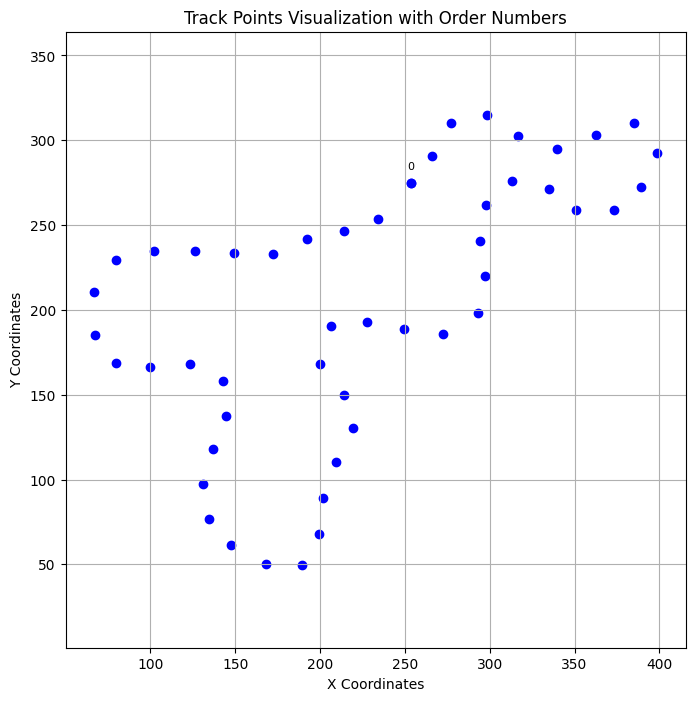

In [5]:
import json
import matplotlib.pyplot as plt
import os

# Define the path to the JSON file
json_file_path = os.path.join(os.getcwd(), 'src/data/convexHull/1725.json')
with open(json_file_path, 'r') as file:
    data = json.load(file)

# Extract points from the JSON dataSet
points = [(item['x'], item['y']) for item in data.get('splineVector', [])]

#print the number of points loaded
print(f'Loaded {len(points)} points from {json_file_path}')

# Separate x and y coordinates
x_coords = [point[0] for point in points]
y_coords = [point[1] for point in points]

# Plot the points using matplotlib
plt.figure(figsize=(8, 8))
plt.scatter(x_coords, y_coords, c='blue', marker='o')
#Annotate one each 100 points with its order number
for i in range(0, len(points), 100):
    plt.annotate(str(i), (x_coords[i], y_coords[i]), textcoords="offset points", xytext=(0,10), ha='center', fontsize=8)

plt.title('Track Points Visualization with Order Numbers')
plt.xlabel('X Coordinates')
plt.ylabel('Y Coordinates')
plt.grid(True)
plt.axis('equal')
plt.show()